# Initial Exploration
`cell-count.csv` 

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('cell-count.csv')
print(df.shape)
df.head(10)

(10500, 15)


,project,subject,condition,age,sex,treatment,response,sample,sample_type,time_from_treatment_start,b_cell,cd8_t_cell,cd4_t_cell,nk_cell,monocyte
0,prj1,sbj000,melanoma,57,M,miraclib,no,sample00000,PBMC,0,10908,24440,20491,13864,23511
1,prj1,sbj000,melanoma,57,M,miraclib,no,sample00001,PBMC,7,6777,19407,33459,18170,23011
2,prj1,sbj000,melanoma,57,M,miraclib,no,sample00002,PBMC,14,9794,22940,24274,17482,18332
3,prj1,sbj001,carcinoma,68,M,miraclib,yes,sample00003,PBMC,0,10081,20271,36157,14041,12610
4,prj1,sbj001,carcinoma,68,M,miraclib,yes,sample00004,PBMC,7,4372,33778,38293,16527,14933
5,prj1,sbj001,carcinoma,68,M,miraclib,yes,sample00005,PBMC,14,15431,31940,30805,11404,15779
6,prj1,sbj002,melanoma,50,M,miraclib,no,sample00006,PBMC,0,5897,31296,28319,12656,21606
7,prj1,sbj002,melanoma,50,M,miraclib,no,sample00007,PBMC,7,10403,13504,33870,22616,18031
8,prj1,sbj002,melanoma,50,M,miraclib,no,sample00008,PBMC,14,8829,26215,21307,17624,16378
9,prj1,sbj003,melanoma,52,M,miraclib,no,sample00009,PBMC,0,7650,33334,21097,18064,15676


## Feature Dictionary

Definitions and Cell types present in the dataset (I used gemini to help define these):

* **Project**: Name or identifier of the specific study, clinical trial, or research initiative.
* **Subject**: Unique identifier for the individual participant or patient.
* **Condition**: Medical status or disease category of the subject (e.g., Melanoma, Healthy Control).
* **Age**: Chronological age of the subject at the time of data collection.
* **Sex**: Biological sex of the subject (typically Male or Female).
* **Treatment**: Specific therapeutic intervention administered to the subject (e.g., Immunotherapy, Placebo).
* **Response**: Clinical outcome or reaction to the treatment (e.g., Responder, Non-responder).
* **Sample**: Unique identifier for the specific biological specimen collected.
* **Sample_type**: Nature or origin of the biological specimen (e.g., Peripheral Blood, Tumor Biopsy).
* **Time_from_treatment_start**: Duration of time elapsed between the initiation of therapy and sample collection.
* **B_cell**: Proportion, count, or expression level of B lymphocytes, which produce antibodies.
* **Cd8_t_cell**: Abundance or level of cytotoxic T cells, responsible for killing infected or cancerous cells.
* **Cd4_t_cell**: Abundance or level of helper T cells, which coordinate the immune response.
* **Nk_cell**: Abundance or level of Natural Killer cells, part of the innate immune system that destroys altered cells.
* **Monocyte**: Abundance or level of monocytes, a type of white blood cell that differentiates into macrophages.

In [43]:
# feature types and null counts, everything looks fine! no cleaning needed
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   project                    10500 non-null  str  
 1   subject                    10500 non-null  str  
 2   condition                  10500 non-null  str  
 3   age                        10500 non-null  int64
 4   sex                        10500 non-null  str  
 5   treatment                  10500 non-null  str  
 6   response                   9078 non-null   str  
 7   sample                     10500 non-null  str  
 8   sample_type                10500 non-null  str  
 9   time_from_treatment_start  10500 non-null  int64
 10  b_cell                     10500 non-null  int64
 11  cd8_t_cell                 10500 non-null  int64
 12  cd4_t_cell                 10500 non-null  int64
 13  nk_cell                    10500 non-null  int64
 14  monocyte                   10500 

## Variable Breakdown

Categorical variables — count of unique values per category.  
Numerical variables — distribution of values.

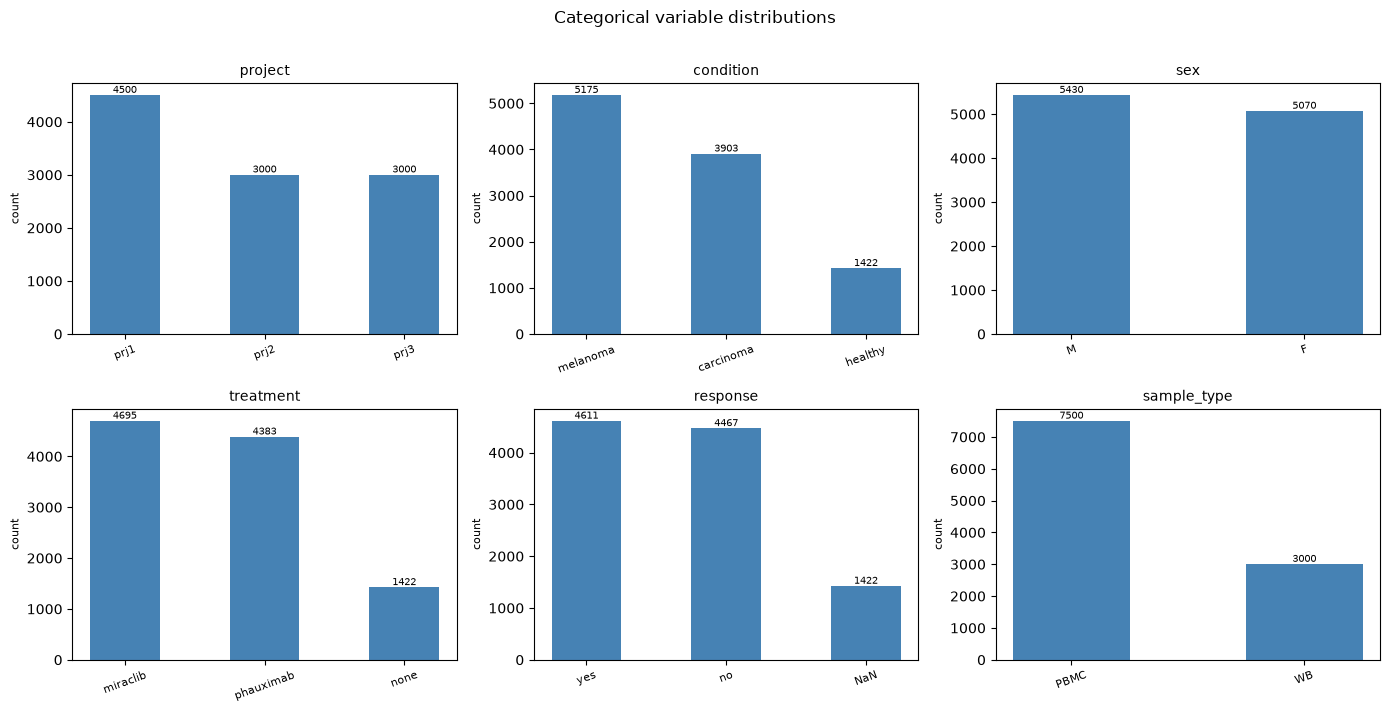

In [44]:
# Categorical variables — bar chart of value counts
cat_cols = ['project', 'condition', 'sex', 'treatment', 'response', 'sample_type']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts(dropna=False)
    labels = [str(x) if pd.notna(x) else 'NaN' for x in counts.index]
    ax.bar(labels, counts.values, color='steelblue', edgecolor='none', width=0.5)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('count', fontsize=8)
    ax.tick_params(axis='x', rotation=20, labelsize=8)
    for i, v in enumerate(counts.values):
        ax.text(i, v + counts.max()*0.01, str(v), ha='center', fontsize=7)

plt.suptitle('Categorical variable distributions', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

Observations:
- `prj1` is the largest project (4,500 samples vs 3,000 each for prj2/prj3); subjects are never shared across projects
- Melanoma is the most common condition; healthy subjects (n=474) are the smallest group and always have `treatment=none` and `response=NaN`
- Sex is roughly balanced (M: 5,430 / F: 5,070)
- `miraclib` has slightly more subjects than `phauximab`; the 1,422 `none` treatment rows map exactly to the healthy group
- PBMC is the dominant sample type (7,500 vs 3,000 WB)

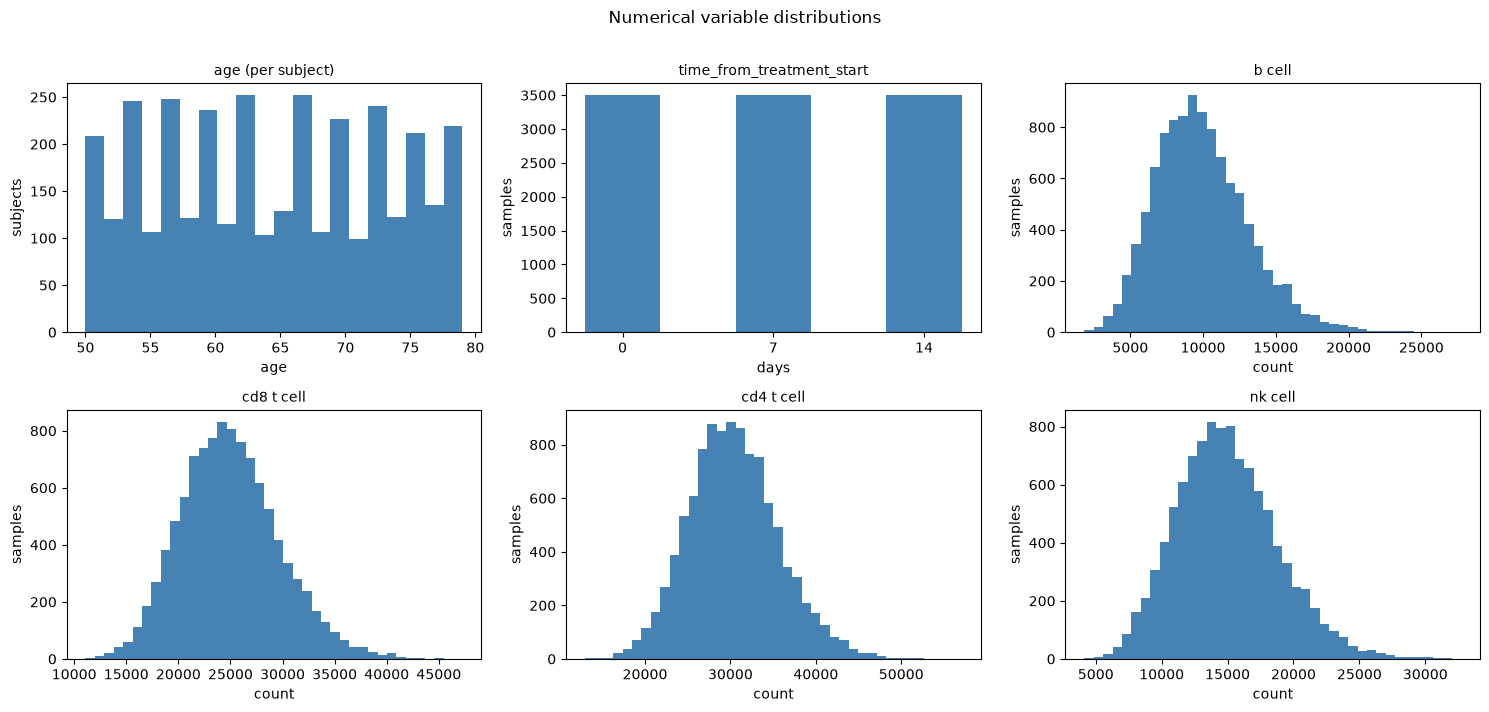

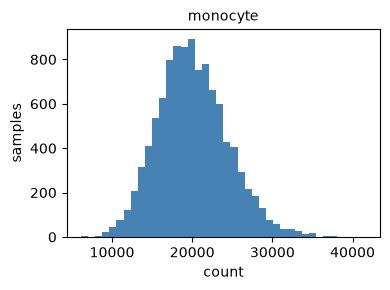

In [ ]:
# Numerical variables — age distribution (subject-level) + cell count distributions
cell_cols = ['b_cell', 'cd8_t_cell', 'cd4_t_cell', 'nk_cell', 'monocyte']
subj = df.drop_duplicates('subject')

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()

# Age
axes[0].hist(subj['age'], bins=20, color='steelblue', edgecolor='none')
axes[0].set_title('age (per subject)', fontsize=10)
axes[0].set_xlabel('age')
axes[0].set_ylabel('subjects')

# Time points
time_counts = df['time_from_treatment_start'].value_counts().sort_index()
axes[1].bar(time_counts.index.astype(str), time_counts.values, color='steelblue', edgecolor='none', width=0.5)
axes[1].set_title('time_from_treatment_start', fontsize=10)
axes[1].set_xlabel('days')
axes[1].set_ylabel('samples')  # evenly distributed — 3500 per timepoint

# Cell counts
for ax, col in zip(axes[2:], cell_cols[:4]):
    ax.hist(df[col], bins=40, color='steelblue', edgecolor='none')
    ax.set_title(col.replace('_',' '), fontsize=10)
    ax.set_xlabel('count')
    ax.set_ylabel('samples')

plt.suptitle('Numerical variable distributions', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

# Remaining cell column
fig2, ax2 = plt.subplots(1, 1, figsize=(4, 3))
ax2.hist(df['monocyte'], bins=40, color='steelblue', edgecolor='none')
ax2.set_title('monocyte', fontsize=10)
ax2.set_xlabel('count')
ax2.set_ylabel('samples')
plt.tight_layout()
plt.show()

Observations:
- Three evenly distributed timepoints (day 0, 7, 14 — 3,500 samples each), consistent with a weekly blood draw protocol
- Cell counts are raw cell counts, not percentages — row sums average ~100,000, which is typical for absolute counts from a cytometry panel
- CD4 T cells are the most abundant population (mean ~30k), B cells the least (~10k)
- All cell count distributions are roughly bell-shaped/normal with no extreme skew, suggesting no major outliers or batch effects

## What does one row represent?

Understanding the granularity is critical for schema design.
Some columns describe the **subject** (fixed per person), others describe the **sample** (change per collection).

In [46]:
cell_cols = ['b_cell', 'cd8_t_cell', 'cd4_t_cell', 'nk_cell', 'monocyte']

# Each subject always has exactly 3 samples (one per timepoint)
print('Samples per subject:', df.groupby('subject')['sample'].count().unique())

# Subject-level fields — should not vary within a subject
subject_variation = df.groupby('subject')[['age', 'sex', 'condition', 'project']].nunique()
print('\nMax unique values per subject for subject-level fields:')
print(subject_variation.max())  # should all be 1

# Sample ID is unique per row
print('\nUnique samples == total rows?', df['sample'].nunique() == len(df))

Samples per subject: [3]

Max unique values per subject for subject-level fields:
age          1
sex          1
condition    1
project      1
dtype: int64

Unique samples == total rows? True


## Study Design Overview

Who is in each project, what treatments were given, and what was the response rate?

In [47]:
# Subject-level view (deduplicate to one row per subject)
subj = df.drop_duplicates('subject')[['subject','project','condition','sex','age','treatment','response']]

print('Subjects per project x condition x treatment:')
subj.groupby(['project','condition','treatment']).size().unstack(fill_value=0)

Subjects per project x condition x treatment:


treatment          miraclib  none  phauximab
project condition                           
prj1    carcinoma       313     0        256
        healthy           0   193          0
        melanoma        384     0        354
prj2    carcinoma       193     0        190
        healthy           0   139          0
        melanoma        229     0        249
prj3    carcinoma       174     0        175
        healthy           0   142          0
        melanoma        272     0        237

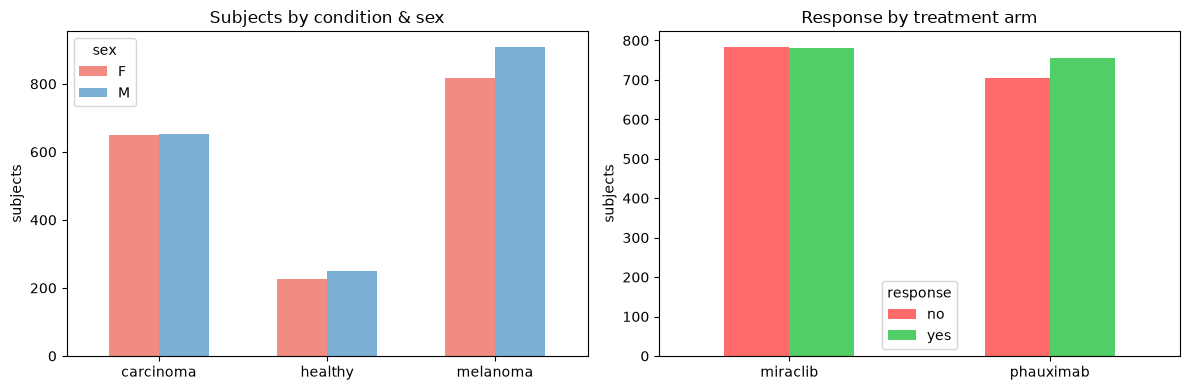


Response rates:
response    no  yes  % yes
treatment                 
miraclib   784  781   49.9
phauximab  705  756   51.7


In [48]:
# Response rates by treatment (excluding healthy/no-treatment)
treated = subj[subj['treatment'] != 'none'].copy()
response_rate = (
    treated.groupby(['treatment','response'])
    .size()
    .unstack()
    .assign(total=lambda x: x.sum(axis=1))
    .assign(pct_yes=lambda x: (x['yes']/x['total']*100).round(1))
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: subject counts by condition, coloured by sex
cond_sex = subj.groupby(['condition','sex']).size().unstack()
cond_sex.plot(kind='bar', ax=axes[0], color=['#f28b82','#7bafd4'], edgecolor='none', width=0.6)
axes[0].set_title('Subjects by condition & sex')
axes[0].set_xlabel('')
axes[0].set_ylabel('subjects')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='sex')

# Right: responder / non-responder counts per treatment
resp_counts = treated.groupby(['treatment','response']).size().unstack()
resp_counts.plot(kind='bar', ax=axes[1], color=['#ff6b6b','#51cf66'], edgecolor='none', width=0.5)
axes[1].set_title('Response by treatment arm')
axes[1].set_xlabel('')
axes[1].set_ylabel('subjects')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='response')

plt.tight_layout()
plt.show()

print('\nResponse rates:')
print(response_rate[['no','yes','pct_yes']].rename(columns={'pct_yes':'% yes'}))

## Cell Population Counts

Values sum to ~100,000 per row — these are **raw cell counts**, not percentages.  
CD4 T cells are the most abundant population; B cells the least.

In [49]:
# Confirm they're counts not percentages
print('Row sum (all 5 populations):')
print(df[cell_cols].sum(axis=1).describe().round(0))

Row sum (all 5 populations):
count     10500.0
mean     100345.0
std        6153.0
min       84247.0
25%       95214.0
50%      100328.0
75%      105341.0
max      122788.0
dtype: float64


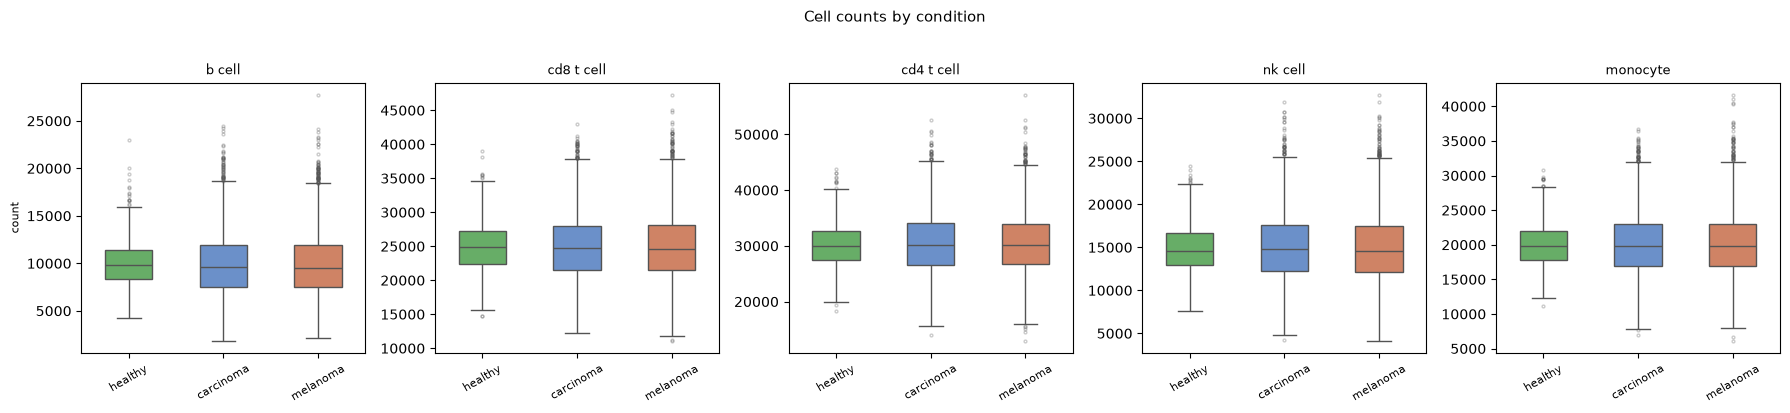

In [ ]:
# Boxplots of each cell type split by condition
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=False)
palette = {'melanoma':'#e07b54','carcinoma':'#5b8dd9','healthy':'#5cb85c'}

for ax, col in zip(axes, cell_cols):
    sns.boxplot(
        data=df, x='condition', y=col, ax=ax,
        hue='condition', palette=palette, order=['healthy','carcinoma','melanoma'],
        legend=False, width=0.5, flierprops=dict(marker='o', markersize=2, alpha=0.3)
    )
    ax.set_title(col.replace('_',' '), fontsize=9)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.set_ylabel('count' if ax == axes[0] else '', fontsize=8)

plt.suptitle('Cell counts by condition', y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

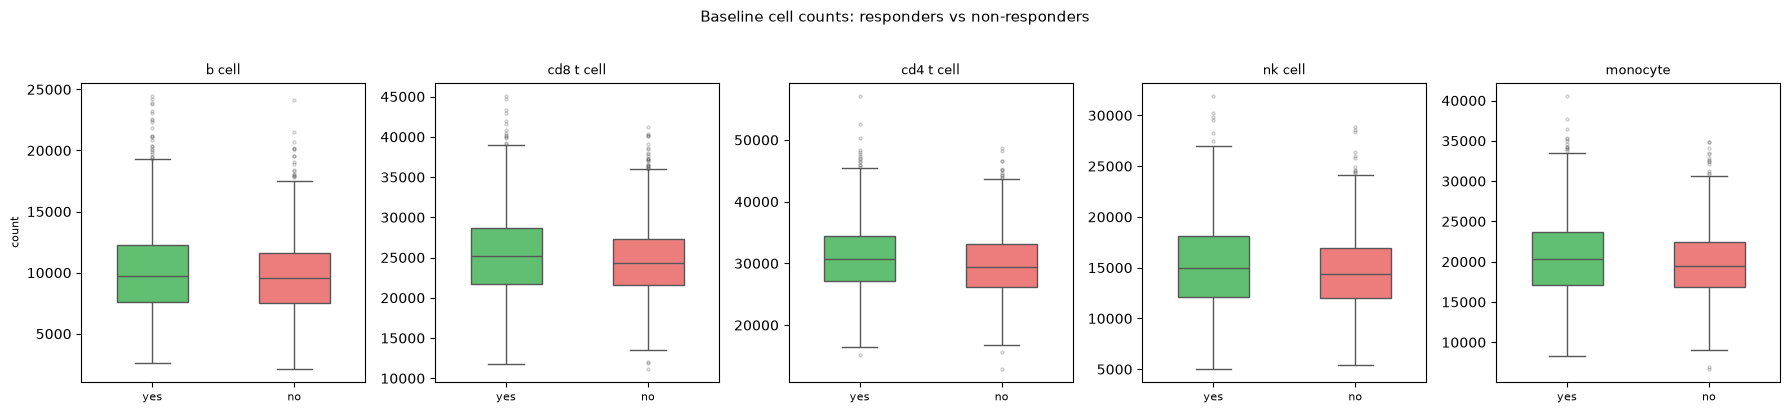

In [ ]:
# Responders vs non-responders (treated subjects only, baseline timepoint)
baseline = df[(df['treatment'] != 'none') & (df['time_from_treatment_start'] == 0)].copy()

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=False)
palette_r = {'yes':'#51cf66','no':'#ff6b6b'}

for ax, col in zip(axes, cell_cols):
    sns.boxplot(
        data=baseline, x='response', y=col, ax=ax,
        hue='response', palette=palette_r, order=['yes','no'],
        legend=False, width=0.5, flierprops=dict(marker='o', markersize=2, alpha=0.3)
    )
    ax.set_title(col.replace('_',' '), fontsize=9)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0, labelsize=8)
    ax.set_ylabel('count' if ax == axes[0] else '', fontsize=8)

plt.suptitle('Baseline cell counts: responders vs non-responders', y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

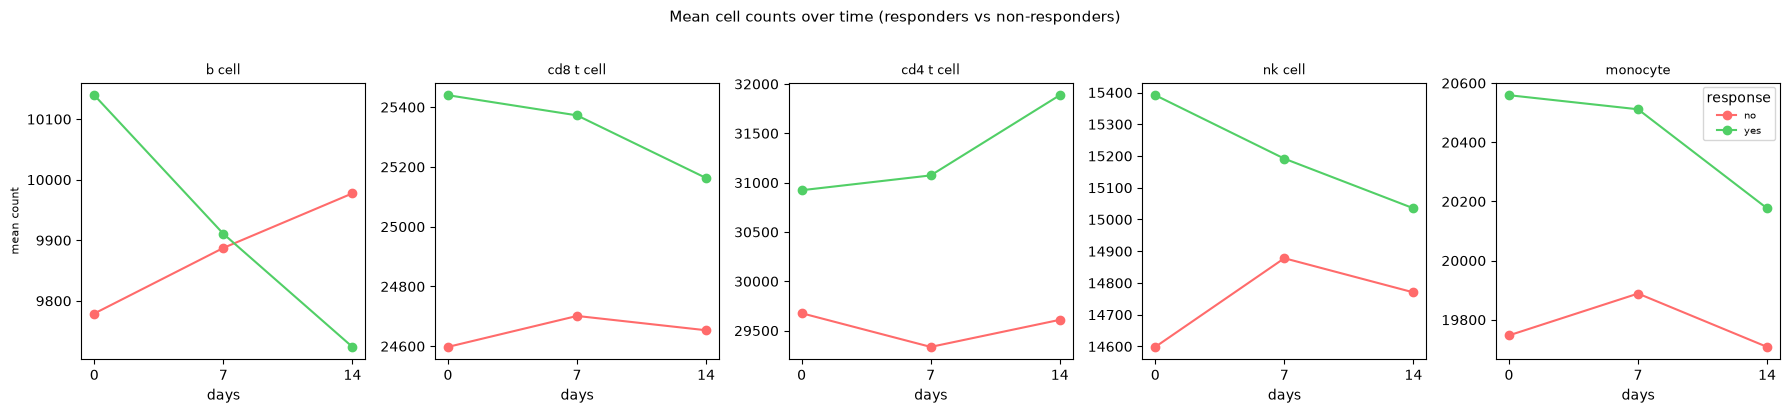

In [52]:
# Do cell counts change over time? Mean per timepoint, by response
time_resp = (
    df[df['treatment'] != 'none']
    .groupby(['time_from_treatment_start','response'])[cell_cols]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=False)
for ax, col in zip(axes, cell_cols):
    for resp, grp in time_resp.groupby('response'):
        ax.plot(grp['time_from_treatment_start'], grp[col],
                marker='o', label=resp,
                color='#51cf66' if resp=='yes' else '#ff6b6b')
    ax.set_title(col.replace('_',' '), fontsize=9)
    ax.set_xlabel('days')
    ax.set_xticks([0,7,14])
    ax.set_ylabel('mean count' if ax == axes[0] else '', fontsize=8)
    if ax == axes[-1]:
        ax.legend(title='response', fontsize=7)

plt.suptitle('Mean cell counts over time (responders vs non-responders)', y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

## Schema Design Notes

Based on the above, the data has a clear hierarchy:

| Level | Fields | Notes |
|---|---|---|
| **project** | project | 3 projects, subjects never shared across projects |
| **subject** | subject, condition, age, sex | Fixed per person; treatment & response also subject-level |
| **sample** | sample, sample_type, time_from_treatment_start | 3 samples per subject (days 0/7/14) |
| **cell_counts** | b_cell, cd8_t_cell, cd4_t_cell, nk_cell, monocyte | 5 populations per sample — store long-format for flexibility |

**treatment** and **response** are subject-level (constant across all samples for a subject) — confirmed above.  
**sample_type** belongs on the sample row.

## Part 2: Initial Analysis
What is the frequency of each cell type (in percentage) for each sample?


In [2]:
import sqlite3
from analysis import get_frequency_table

con = sqlite3.connect("teiko.db")
freq_df = get_frequency_table(con)
freq_df.head(15)
# sums to 100% per sample, as expected

,sample,total_count,population,count,percentage
0,sample00000,93214,b_cell,10908,11.7021
1,sample00000,93214,cd4_t_cell,20491,21.9827
2,sample00000,93214,cd8_t_cell,24440,26.2192
3,sample00000,93214,monocyte,23511,25.2226
4,sample00000,93214,nk_cell,13864,14.8733
5,sample00001,100824,b_cell,6777,6.7216
6,sample00001,100824,cd4_t_cell,33459,33.1856
7,sample00001,100824,cd8_t_cell,19407,19.2484
8,sample00001,100824,monocyte,23011,22.8229
9,sample00001,100824,nk_cell,18170,18.0215


## Part 3: Statistical Analysis
Check group distributions for deciding the statistical test

Samples per group (each subject contributes 3 rows — one per timepoint):
response
yes    993
no     975

Subjects per group (unique patients):
response
yes    331
no     325

Note: test runs on 1968 samples from 656 subjects


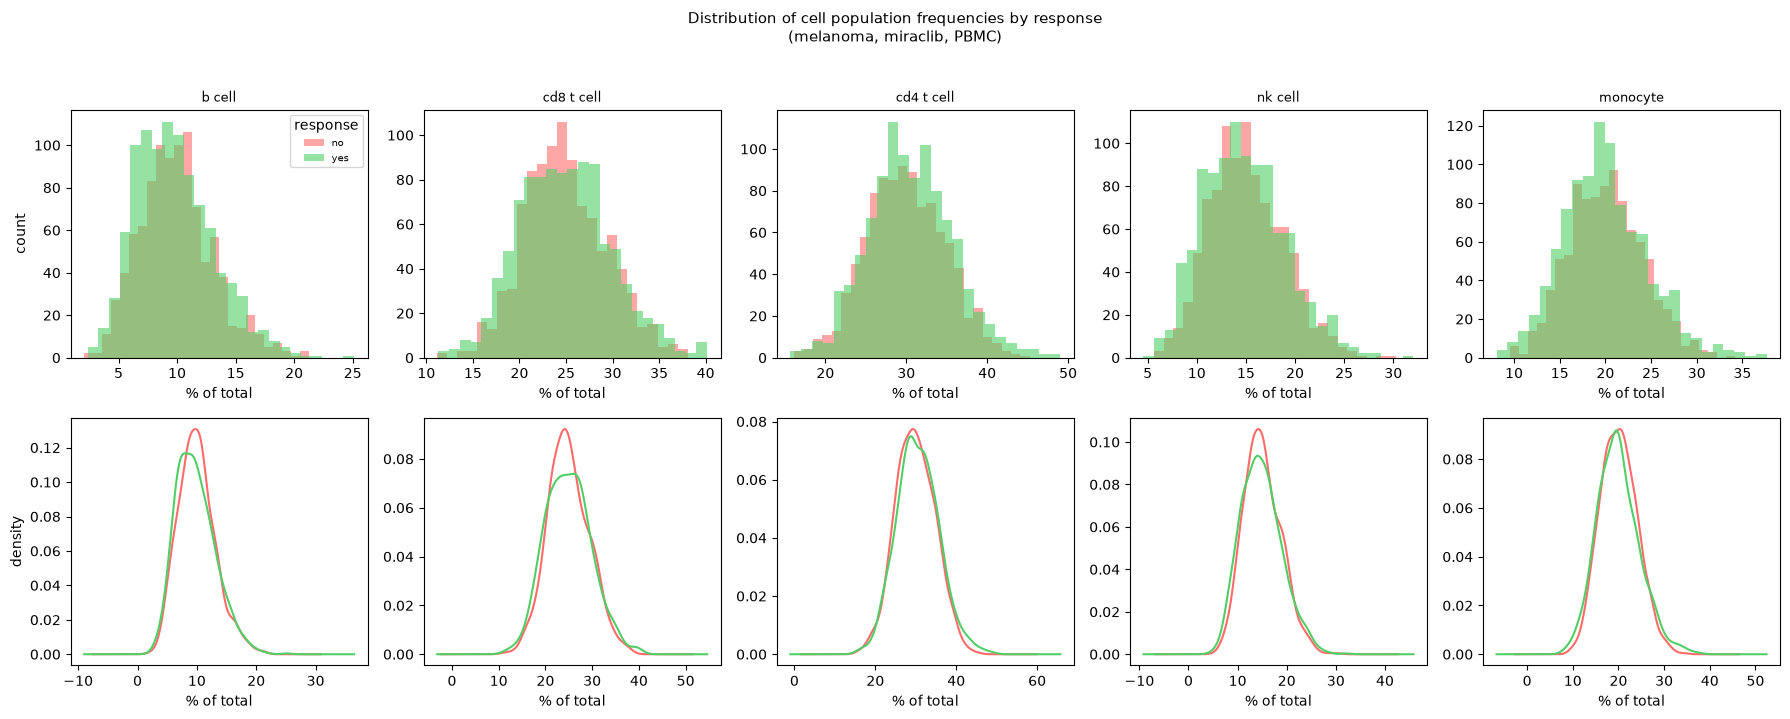

In [3]:
from analysis import check_groups, run_stats
check_groups(freq_df, con)

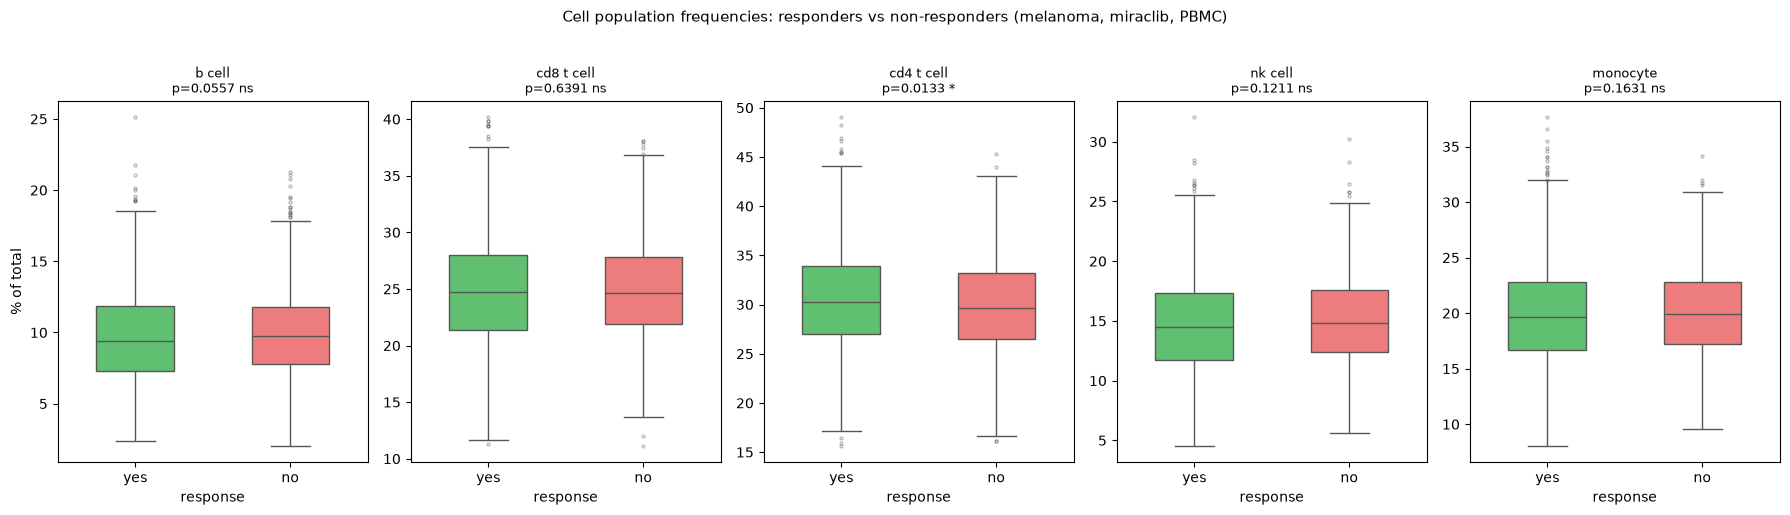


Mann-Whitney U results:
population  responder_median  non_responder_median  p_value  significant
    b_cell            9.4323                9.7884   0.0557        False
cd8_t_cell           24.7280               24.6031   0.6391        False
cd4_t_cell           30.2206               29.6576   0.0133         True
   nk_cell           14.5093               14.7991   0.1211        False
  monocyte           19.6097               19.9423   0.1631        False


,population,responder_median,non_responder_median,p_value,significant
0,b_cell,9.4323,9.7884,0.0557,False
1,cd8_t_cell,24.7280,24.6031,0.6391,False
2,cd4_t_cell,30.2206,29.6576,0.0133,True
3,nk_cell,14.5093,14.7991,0.1211,False
4,monocyte,19.6097,19.9423,0.1631,False


In [4]:
stats_df = run_stats(freq_df, con)
stats_df

In [5]:
from analysis import compare_tests
compare_tests(freq_df, con)

Mann-Whitney vs Welch's t-test comparison:
population  responder_median  non_responder_median  p_mannwhitney  p_welch  sig_mw  sig_welch  consistent
    b_cell            9.4323                9.7884         0.0557   0.1712   False      False        True
cd8_t_cell           24.7280               24.6031         0.6391   0.7685   False      False        True
cd4_t_cell           30.2206               29.6576         0.0133   0.0050    True       True        True
   nk_cell           14.5093               14.7991         0.1211   0.1926   False      False        True
  monocyte           19.6097               19.9423         0.1631   0.4658   False      False        True


,population,responder_median,non_responder_median,p_mannwhitney,p_welch,sig_mw,sig_welch,consistent
0,b_cell,9.4323,9.7884,0.0557,0.1712,False,False,True
1,cd8_t_cell,24.7280,24.6031,0.6391,0.7685,False,False,True
2,cd4_t_cell,30.2206,29.6576,0.0133,0.0050,True,True,True
3,nk_cell,14.5093,14.7991,0.1211,0.1926,False,False,True
4,monocyte,19.6097,19.9423,0.1631,0.4658,False,False,True


Seems like only cd4_t_cell counts are significantly different between responders (higher) and non-responders (lower), and b_cell counts are borderline significant (lower in responders). All other cell populations show no significant difference between response groups. Results are consistent with the Welch's test (which is more statistically powered), but look like the Mann-Whitney may be more suited due to slightly different distributions between the two groups

## Part 4: Subset Analysis

In [6]:
from analysis import run_subset
subset = run_subset(con)

Samples per project:
project  n_samples
   prj1        384
   prj3        272

Subjects by response:
response  n_subjects
     yes         331
      no         325

Subjects by sex:
sex  n_subjects
  M         344
  F         312

Avg B cells (melanoma male responders, time=0, all samples/treatments): 10206.15


In [7]:
# inspect the raw baseline dataframe
subset['baseline'].head(10)

,sample_id,subject_id,project_id,response,sex
0,sample00000,sbj000,prj1,no,M
1,sample00006,sbj002,prj1,no,M
2,sample00009,sbj003,prj1,no,M
3,sample00024,sbj008,prj1,yes,F
4,sample00060,sbj020,prj1,yes,F
5,sample00066,sbj022,prj1,yes,M
6,sample00072,sbj024,prj1,no,M
7,sample00075,sbj025,prj1,yes,F
8,sample00081,sbj027,prj1,no,F
9,sample00123,sbj041,prj1,no,F
